 # XGBoost Emotion Classification Analysis

 Comparing TF-IDF, Word2Vec, and GloVe features using XGBoost.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.preprocessing import LabelEncoder

# Import your custom modules
from src.data.train_dataset_EDA import load_train_with_features, load_test_with_features
from src.features.tfidf import fit_tfidf_on_clean_text_column
from src.data.dataset import Label_map 
from src.features.glove import build_glove_features, sequences_to_vectors
from src.features.word2vec import build_and_train_w2v_model, get_mean_vectors

e:\Projects\movie-review-emotion-classifier\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


 ## 1. Load Data & Distribution

In [2]:
train_df = load_train_with_features()
test_df = load_test_with_features()

print("Train df:", train_df.shape)
print("Test df:", test_df.shape)

train_df.head()


Train df: (16000, 6)
Test df: (2000, 6)


,text,label,char_len,word_len,clean_text,clean_word_len
0,i didnt feel humiliated,0,23,4,i didnt feel humiliated,4
1,i can go from feeling so hopeless to so damned...,0,108,21,i can go from feeling so hopeless to so damned...,21
2,im grabbing a minute to post i feel greedy wrong,3,48,10,im grabbing a minute to post i feel greedy wrong,10
3,i am ever feeling nostalgic about the fireplac...,2,92,18,i am ever feeling nostalgic about the fireplac...,18
4,i am feeling grouchy,3,20,4,i am feeling grouchy,4


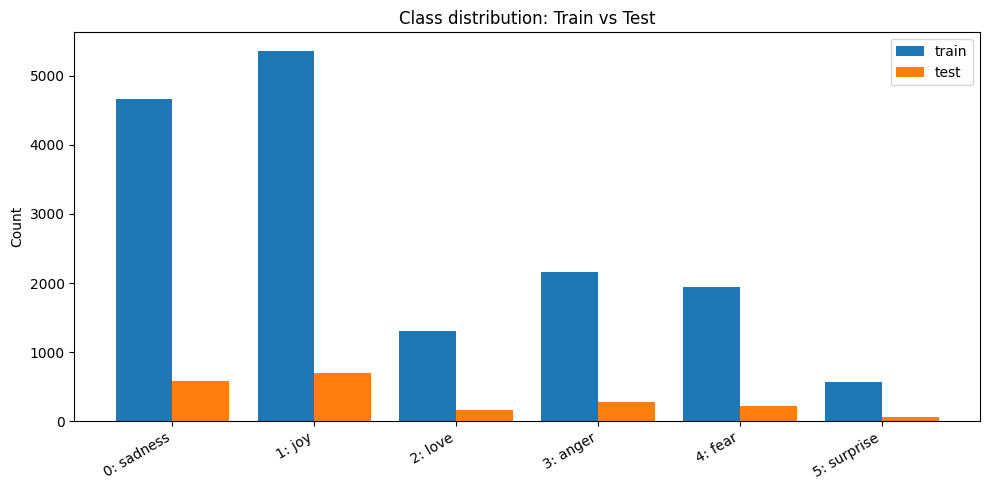

In [3]:
# Visualizing Class Distribution
train_counts = train_df["label"].value_counts().sort_index()
test_counts = test_df["label"].value_counts().sort_index()

labels = [f"{i}: {Label_map[i]}" for i in train_counts.index]
x = np.arange(len(labels))
width = 0.4

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, train_counts.values, width, label="train")
plt.bar(x + width/2, test_counts.values, width, label="test")
plt.xticks(x, labels, rotation=30, ha="right")
plt.title("Class distribution: Train vs Test")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


 ## 2. Experiment A: TF-IDF + XGBoost

In [4]:
# 1. Vectorize
# Note: Ensure fit_tfidf_on_clean_text_column uses ngram_range=(1,2) for best results
vectorizer, X_train_tfidf, y_train = fit_tfidf_on_clean_text_column()

X_test_text = test_df["clean_text"]
y_test = test_df["label"].values
X_test_tfidf = vectorizer.transform(X_test_text)

print("X_train (TF-IDF):", X_train_tfidf.shape)
print("X_test  (TF-IDF):", X_test_tfidf.shape)


X_train (TF-IDF): (16000, 20000)
X_test  (TF-IDF): (2000, 20000)


In [5]:
# 2. Train XGBoost
model_tfidf = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(Label_map),
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    n_jobs=-1,
    random_state=42
)

model_tfidf.fit(X_train_tfidf, y_train)

# 3. Predict
y_pred_tfidf = model_tfidf.predict(X_test_tfidf)


              precision    recall  f1-score   support

           0       0.94      0.88      0.91       581
           1       0.81      0.93      0.86       695
           2       0.78      0.70      0.74       159
           3       0.93      0.80      0.86       275
           4       0.92      0.80      0.86       224
           5       0.63      0.79      0.70        66

    accuracy                           0.86      2000
   macro avg       0.83      0.82      0.82      2000
weighted avg       0.87      0.86      0.86      2000



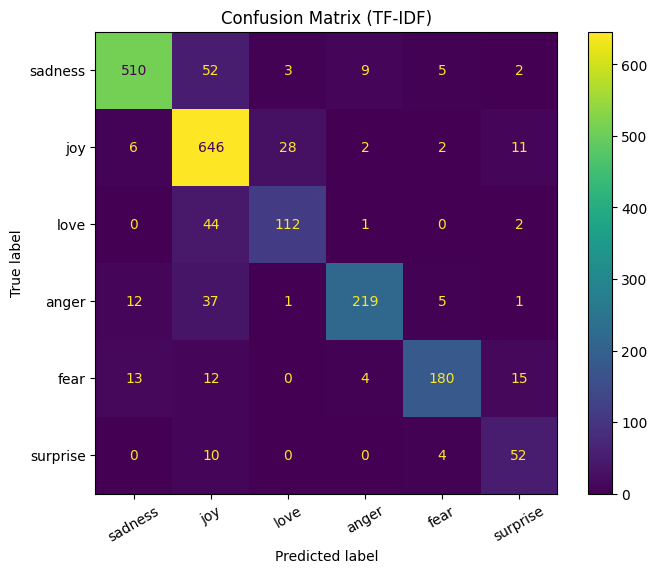

In [6]:
# 4. Evaluate
report_tfidf = classification_report(y_test, y_pred_tfidf, output_dict=True)
print(classification_report(y_test, y_pred_tfidf))

# Confusion Matrix
cm_tfidf = confusion_matrix(y_test, y_pred_tfidf, labels=sorted(Label_map.keys()))
disp_tfidf = ConfusionMatrixDisplay(confusion_matrix=cm_tfidf, display_labels=[Label_map[i] for i in sorted(Label_map.keys())])

fig, ax = plt.subplots(figsize=(8, 6))
disp_tfidf.plot(ax=ax, xticks_rotation=30)
plt.title("Confusion Matrix (TF-IDF)")
plt.show()


 ## 3. Experiment B: Word2Vec + XGBoost

In [7]:
# 1. Train Word2Vec
w2v_model = build_and_train_w2v_model(
    train_df["clean_text"], 
    vector_size=100, 
    window=5, 
    min_count=2
)
# 2. Vectorize (Mean + Max Pooling)
X_train_w2v = get_mean_vectors(w2v_model, train_df["clean_text"])
X_test_w2v  = get_mean_vectors(w2v_model, test_df["clean_text"])

print("X_train (W2V):", X_train_w2v.shape)


X_train (W2V): (16000, 200)


In [8]:
# 3. Train XGBoost
model_w2v = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(Label_map),
    n_estimators=100,
    n_jobs=-1,
    random_state=42
)

model_w2v.fit(X_train_w2v, y_train)
y_pred_w2v = model_w2v.predict(X_test_w2v)


              precision    recall  f1-score   support

           0       0.51      0.66      0.57       581
           1       0.59      0.78      0.67       695
           2       0.53      0.15      0.24       159
           3       0.51      0.26      0.34       275
           4       0.56      0.34      0.43       224
           5       0.45      0.08      0.13        66

    accuracy                           0.55      2000
   macro avg       0.53      0.38      0.40      2000
weighted avg       0.54      0.55      0.52      2000



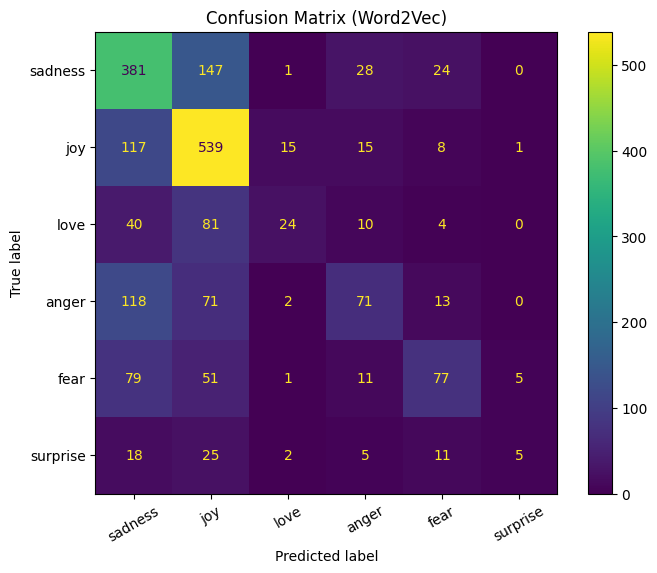

In [9]:
# 4. Evaluate
print(classification_report(y_test, y_pred_w2v))

cm_w2v = confusion_matrix(y_test, y_pred_w2v, labels=sorted(Label_map.keys()))
disp_w2v = ConfusionMatrixDisplay(confusion_matrix=cm_w2v, display_labels=[Label_map[i] for i in sorted(Label_map.keys())])

fig, ax = plt.subplots(figsize=(8, 6))
disp_w2v.plot(ax=ax, xticks_rotation=30)
plt.title("Confusion Matrix (Word2Vec)")
plt.show()


 ## 4. Experiment C: GloVe + XGBoost

In [10]:
# 1. Load Sequences
X_train_seq, y_train, X_test_seq, y_test, tokenizer, embedding_matrix, num_words = (
    build_glove_features()
)

# 2. Convert to Vectors (Mean + Max Pooling)
X_train_glove = sequences_to_vectors(X_train_seq, embedding_matrix)
X_test_glove  = sequences_to_vectors(X_test_seq, embedding_matrix)

print("X_train (GloVe):", X_train_glove.shape)


X_train (GloVe): (16000, 200)


In [11]:
# 3. Train XGBoost
# Note: XGBoost is robust to scaling, so we skip StandardScaler here
model_glove = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(Label_map),
    n_estimators=100,
    n_jobs=-1,
    random_state=42
)

model_glove.fit(X_train_glove, y_train)
y_pred_glove = model_glove.predict(X_test_glove)


              precision    recall  f1-score   support

           0       0.76      0.78      0.77       581
           1       0.70      0.85      0.77       695
           2       0.71      0.50      0.59       159
           3       0.82      0.67      0.73       275
           4       0.79      0.65      0.71       224
           5       0.68      0.39      0.50        66

    accuracy                           0.74      2000
   macro avg       0.74      0.64      0.68      2000
weighted avg       0.74      0.74      0.73      2000



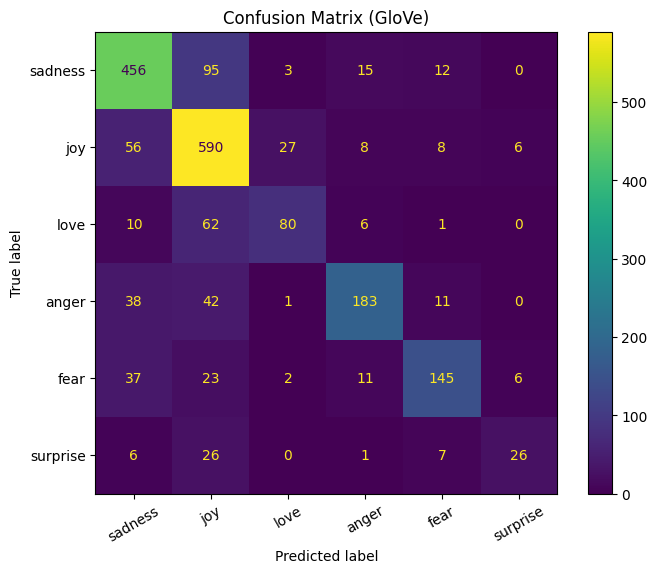

In [12]:
# 4. Evaluate
print(classification_report(y_test, y_pred_glove))

cm_glove = confusion_matrix(y_test, y_pred_glove, labels=sorted(Label_map.keys()))
disp_glove = ConfusionMatrixDisplay(confusion_matrix=cm_glove, display_labels=[Label_map[i] for i in sorted(Label_map.keys())])

fig, ax = plt.subplots(figsize=(8, 6))
disp_glove.plot(ax=ax, xticks_rotation=30)
plt.title("Confusion Matrix (GloVe)")
plt.show()


 ## 5. Final Comparison

TF-IDF Accuracy:   85.95%
Word2Vec Accuracy: 54.85%
GloVe Accuracy:    74.00%


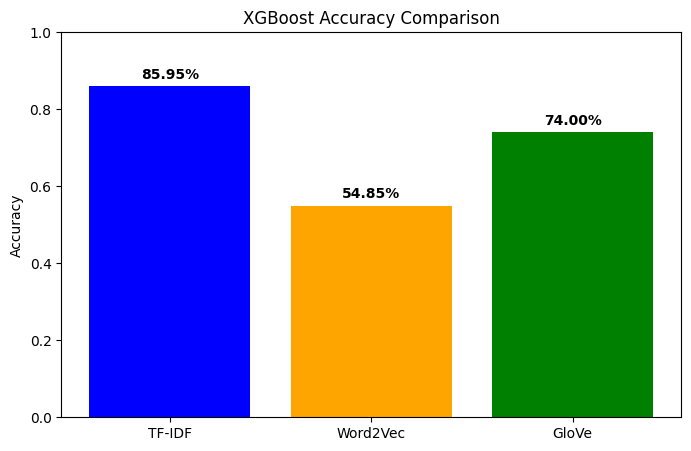

In [14]:
acc_tfidf = accuracy_score(y_test, y_pred_tfidf)
acc_w2v   = accuracy_score(y_test, y_pred_w2v)
acc_glove = accuracy_score(y_test, y_pred_glove)

print(f"TF-IDF Accuracy:   {acc_tfidf:.2%}")
print(f"Word2Vec Accuracy: {acc_w2v:.2%}")
print(f"GloVe Accuracy:    {acc_glove:.2%}")

# Plot
results = pd.DataFrame({
    'Model': ['TF-IDF', 'Word2Vec', 'GloVe'],
    'Accuracy': [acc_tfidf, acc_w2v, acc_glove]
})

plt.figure(figsize=(8, 5))
plt.bar(results['Model'], results['Accuracy'], color=['blue', 'orange', 'green'])
plt.ylim(0, 1.0)
plt.title("XGBoost Accuracy Comparison")
plt.ylabel("Accuracy")
for i, v in enumerate(results['Accuracy']):
    plt.text(i, v + 0.02, f"{v:.2%}", ha='center', fontweight='bold')
plt.show()

🔄 Generating Augmented Data...
Original size: 16000 -> Augmented size: 32172

🔹 Training TF-IDF (Augmented)...
Result: 88.00%

🔹 Training Word2Vec (Augmented)...
Result: 66.20%

🔹 Training GloVe (Augmented)...
Result: 76.00%

📊 Plotting Results...


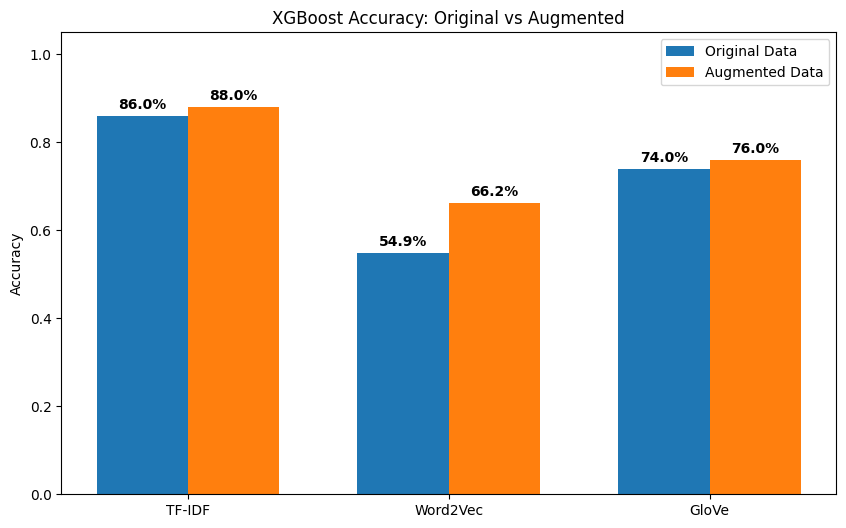

In [24]:
# %% [markdown]
# ## 6. Data Augmentation & Final Comparison (Clean Version)

# %%
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer

# --- IMPORTS ΑΠΟ ΤΑ ΑΡΧΕΙΑ ΣΟΥ ---
from src.data.augmentation import AugmentConfig, class_balanced_augment
from src.features.word2vec import build_and_train_w2v_model, get_mean_vectors
from src.data.dataset import Label_map

# Εδώ καλούμε τις συναρτήσεις όπως ακριβώς τις έχεις στο glove.py
from src.features.glove import build_glove_features_from_dfs, sequences_to_vectors

# --- 1. ΔΗΜΙΟΥΡΓΙΑ AUGMENTED DATA ---
print("🔄 Generating Augmented Data...")
aug_cfg = AugmentConfig(mode="eda", n_aug_per_sample=1, keep_original=True, seed=42)
train_df_aug = class_balanced_augment(train_df, text_col='clean_text', label_col='label', config=aug_cfg)
print(f"Original size: {len(train_df)} -> Augmented size: {len(train_df_aug)}")


# --- 2. TRAIN XGBOOST (TF-IDF AUGMENTED) ---
print("\n🔹 Training TF-IDF (Augmented)...")
tfidf_aug = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf_aug = tfidf_aug.fit_transform(train_df_aug['clean_text'])
X_test_tfidf_aug = tfidf_aug.transform(test_df['clean_text'])

model_tfidf_aug = xgb.XGBClassifier(objective='multi:softmax', num_class=len(Label_map), n_estimators=100, n_jobs=-1, random_state=42)
model_tfidf_aug.fit(X_train_tfidf_aug, train_df_aug['label'])
acc_tfidf_aug = accuracy_score(test_df['label'], model_tfidf_aug.predict(X_test_tfidf_aug))
print(f"Result: {acc_tfidf_aug:.2%}")


# --- 3. TRAIN XGBOOST (WORD2VEC AUGMENTED) ---
print("\n🔹 Training Word2Vec (Augmented)...")
w2v_model_aug = build_and_train_w2v_model(train_df_aug["clean_text"], vector_size=100, window=5, min_count=2)
X_train_w2v_aug = get_mean_vectors(w2v_model_aug, train_df_aug["clean_text"])
X_test_w2v_aug = get_mean_vectors(w2v_model_aug, test_df["clean_text"])

model_w2v_aug = xgb.XGBClassifier(objective='multi:softmax', num_class=len(Label_map), n_estimators=100, n_jobs=-1, random_state=42)
model_w2v_aug.fit(X_train_w2v_aug, train_df_aug['label'])
acc_w2v_aug = accuracy_score(test_df['label'], model_w2v_aug.predict(X_test_w2v_aug))
print(f"Result: {acc_w2v_aug:.2%}")


# --- 4. TRAIN XGBOOST (GLOVE AUGMENTED) ---
print("\n🔹 Training GloVe (Augmented)...")

# Χρησιμοποιούμε τη δική σου συνάρτηση που τα κάνει όλα αυτόματα (Tokenization + Matrix Creation)
# Περνάμε το path για σιγουριά (αν τρέχεις από root folder του project)
glove_path_arg = "data/glove.6B.100d.txt" 

X_train_seq_aug, _, X_test_seq_aug, _, _, embedding_matrix_aug, _ = build_glove_features_from_dfs(
    train_df_aug, 
    test_df, 
    text_col="clean_text", 
    label_col="label",
    glove_path=glove_path_arg 
)

# Μετατροπή σε vectors (Mean + Max) με τη δική σου συνάρτηση
X_train_glove_aug = sequences_to_vectors(X_train_seq_aug, embedding_matrix_aug)
X_test_glove_aug = sequences_to_vectors(X_test_seq_aug, embedding_matrix_aug)

model_glove_aug = xgb.XGBClassifier(objective='multi:softmax', num_class=len(Label_map), n_estimators=100, n_jobs=-1, random_state=42)
model_glove_aug.fit(X_train_glove_aug, train_df_aug['label'])
acc_glove_aug = accuracy_score(test_df['label'], model_glove_aug.predict(X_test_glove_aug))
print(f"Result: {acc_glove_aug:.2%}")


# --- 5. FINAL PLOT ---
print("\n📊 Plotting Results...")
methods = ['TF-IDF', 'Word2Vec', 'GloVe']

# Αν δεν υπάρχουν οι μεταβλητές από τα προηγούμενα κελιά (Original), βάζουμε 0
try:
    original_scores = [acc_tfidf, acc_w2v, acc_glove]
except NameError:
    print("⚠️ Warning: Original scores missing. Using placeholders.")
    original_scores = [0, 0, 0]

augmented_scores = [acc_tfidf_aug, acc_w2v_aug, acc_glove_aug]

x = np.arange(len(methods))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, original_scores, width, label='Original Data', color='#1f77b4')
rects2 = ax.bar(x + width/2, augmented_scores, width, label='Augmented Data', color='#ff7f0e')

ax.set_ylabel('Accuracy')
ax.set_title('XGBoost Accuracy: Original vs Augmented')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylim(0, 1.05)
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        if height > 0:
            ax.annotate(f'{height:.1%}', xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontweight='bold')

autolabel(rects1)
autolabel(rects2)
plt.show()